# Credit default risk: modeling & explainability

End-to-end credit default model on the German Credit dataset (1000 applicants, 30% bad payers). The point is not only to predict default but to be able to understand every single decision and to check that the model is not discriminating, so most of the effort goes on the use of XAI (SHAP + LIME) and on a fairness audit of the protected attribute `Sex`.

The features are engineered upstream in SQL on BigQuery (`query_credit_risk.sql`) and exported to `credit_features.csv`; here I consume that table and run the modeling side. I go through the pipeline in order and justify each choice as I go: data and EDA, preprocessing and a leakage-free feature build, a multicollinearity check, model selection and the decision threshold, then SHAP, LIME and the fairness audit.

## Setup

I import the libraries and fix a global seed, so everything downstream of the split is reproducible. `credit_features.csv` is the table exported from BigQuery, so the notebook runs as-is; to rebuild it from the warehouse you would need `gcloud auth application-default login` and the query in `query_credit_risk.sql`, but the CSV is only a frozen copy of that query output so the result is the same.

In [31]:
%matplotlib inline
import json
import os
import warnings
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr

for _cat in (FutureWarning, DeprecationWarning, UserWarning):
    warnings.filterwarnings("ignore", category=_cat)
RANDOM_STATE = 42
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Data: sources and choices

One row per applicant, target `default_flag` (1 = bad payer). The class balance is 70/30: imbalanced, as credit data usually is, and that imbalance drives a few choices later (the PR curve instead of ROC alone, the cost-based threshold). I keep the feature engineering in SQL on purpose: extraction and feature building in the warehouse, modeling in Python, which is the realistic split in a real pipeline.

In [32]:
df = pd.read_csv("credit_features.csv")
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns.")
print("Target distribution:\n", df["default_flag"].value_counts(), "\n")

Loaded 1000 rows, 19 columns.
Target distribution:
 default_flag
0    700
1    300
Name: count, dtype: int64 



## Exploratory data analysis

Two quick reads before any modeling.

Default rate by purpose (Fig. 1a). I annotate the sample size `n` on each bar on purpose: a couple of categories (vacation/others, domestic appliances) have very few clients, so their ~40% rate is noisy and should not be over-read.

Default rate by amount (Fig. 1b). A raw frequency histogram would be dominated by the 70/30 imbalance (the "good" bars always look taller), so instead I bin the amount into equal-size quantile bands and plot the default rate in each. The read is clean: only the top band is clearly riskier (~42% vs the 30% baseline), the lower bands all sit around the base rate.

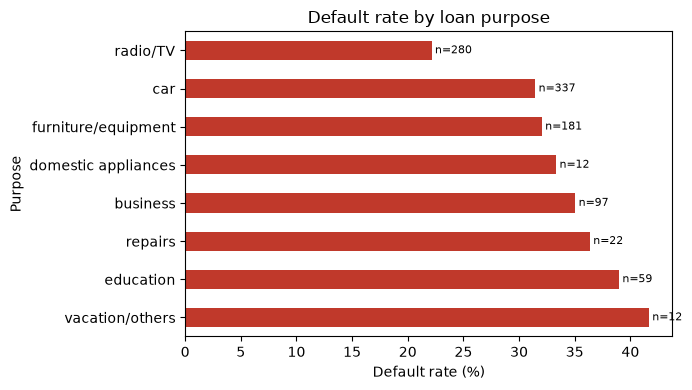

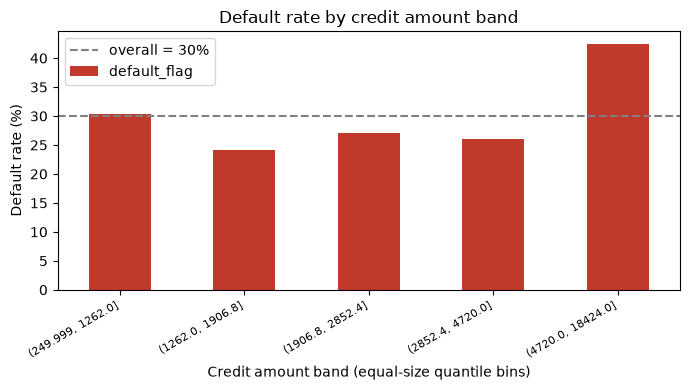

In [33]:
purpose_rate = (df.groupby("Purpose")["default_flag"].mean().sort_values(ascending=False) * 100)
purpose_n = df["Purpose"].value_counts().reindex(purpose_rate.index)
ax = purpose_rate.plot(kind="barh", color="#c0392b", figsize=(7, 4))
ax.set_xlabel("Default rate (%)")
ax.set_title("Default rate by loan purpose")
for i, n in enumerate(purpose_n.values):
    ax.text(purpose_rate.iloc[i] + 0.3, i, f"n={n}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_default_by_purpose.png", dpi=120)
plt.show()

amount_band = pd.qcut(df["Credit_amount"], q=5)
rate_by_amount = df.groupby(amount_band, observed=True)["default_flag"].mean() * 100
ax = rate_by_amount.plot(kind="bar", color="#c0392b", figsize=(7, 4))
ax.set_xlabel("Credit amount band (equal-size quantile bins)")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate by credit amount band")
ax.axhline(df["default_flag"].mean() * 100, color="grey", linestyle="--",
           label=f"overall = {df['default_flag'].mean() * 100:.0f}%")
ax.legend()
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_default_by_amount.png", dpi=120)
plt.show()

## Preprocessing

Missing values in the two account columns are informative (they mean "no account on record"), so I keep them as an explicit `missing` category instead of dropping the rows.

Then I drop three columns that are just a second encoding of another one, to avoid collinearity: `age_band` (binning loses information vs the continuous `Age`), the numeric `Job` code (I keep the readable one-hot `job_desc` instead, since the 0–3 code is not cleanly ordinal: 0 and 1 differ by residency, not skill), and `checking_missing` (already carried by the `Checking_account_missing` dummy).

Why one-hot and not a single integer per category. A label encoding (car=0, radio/TV=1, …) would invent a false order and false distances between nominal categories: the model would read `business=2` as twice `radio/TV=1`, which is meaningless. One-hot gives each category an independent 0/1 column, so no fake ordering. Label encoding would only be valid for genuinely ordinal variables.

In [34]:
y = df["default_flag"]
X = df.drop(columns=["default_flag"])

for col in ["Saving_accounts", "Checking_account"]:
    X[col] = X[col].fillna("missing")

X = X.drop(columns=["age_band", "Job", "checking_missing"])

X = X.drop(columns=["amount_vs_purpose_avg", "high_amount"])

## Train/test split

I split before any data-dependent transformation. I also keep the readable `Sex` column aside here, because the one-hot step below turns it into dummies and I need the readable label later for the fairness audit.

In [35]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train_raw.shape[0]} rows  Test: {X_test_raw.shape[0]} rows\n")

sex_test = X_test_raw["Sex"].copy()

Train: 800 rows  Test: 200 rows



## Feature engineering (leakage-free)

Two features use cross-row statistics (deviation of the amount from its per-purpose mean, and a "high amount" flag vs the 75th percentile). I recompute them with statistics fit on the training set only, then apply them to both splits. The one-hot encoding is fit on the train frame too, and the test frame is reindexed onto the train columns (unseen category → all-zero column, missing column → 0), which is exactly what a model in production does when it maps a new applicant onto the columns it already knows.

In [36]:
def add_train_fit_features(train_raw, test_raw):
    """Recompute the two cross-row features using training statistics only."""
    tr, te = train_raw.copy(), test_raw.copy()

    purpose_mean = tr.groupby("Purpose")["Credit_amount"].mean()
    global_mean = tr["Credit_amount"].mean()
    for frame in (tr, te):
        mapped = frame["Purpose"].map(purpose_mean).fillna(global_mean)
        frame["amount_vs_purpose_avg"] = (frame["Credit_amount"] - mapped).round(0)

    q75 = tr["Credit_amount"].quantile(0.75)
    for frame in (tr, te):
        frame["high_amount"] = (frame["Credit_amount"] > q75).astype(int)

    return tr, te

X_train_raw, X_test_raw = add_train_fit_features(X_train_raw, X_test_raw)

categorical_cols = X_train_raw.select_dtypes(include=["object", "string"]).columns.tolist()
X_train = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=False).astype(float)
X_test = (pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=False)
            .astype(float)
            .reindex(columns=X_train.columns, fill_value=0.0))
print(f"Features after encoding: {X_train.shape[1]} columns "
      f"({len(categorical_cols)} categoricals one-hot encoded).\n")

Features after encoding: 35 columns (6 categoricals one-hot encoded).



## Multicollinearity (VIF)

Several engineered features are derived from `Credit_amount`, so they are strongly correlated. Collinearity does not hurt the predictive accuracy of tree ensembles, but it does corrupt the explanations: SHAP splits one real effect arbitrarily across the correlated proxies, and LIME's independent perturbation builds impossible points. Since this project is about explainability, I check it with the Variance Inflation Factor (VIF = 1/(1−R²)) and drop the redundant derived features, keeping the readable base feature `Credit_amount`.

The before/after is the proof: `Credit_amount` goes from VIF ≈ 24 (severe) back to ≈ 4.6 once the two proxies are dropped since they were measuring the same thing. I keep `amount_per_month` (VIF < 3): dividing by duration de-correlates it, so it carries genuinely independent signal. Pruning the two collinear features left the CV-AUC unchanged (it even nudged up a touch), which confirms they were noise, not signal.

In [37]:
def compute_vif(frame, cols):
    vif = {}
    for col in cols:
        others = [c for c in cols if c != col]
        r2 = LinearRegression().fit(frame[others], frame[col]).score(frame[others], frame[col])
        vif[col] = 1.0 / (1.0 - r2) if r2 < 1 else float("inf")
    return pd.Series(vif).sort_values(ascending=False)

continuous_cols = ["Age", "Credit_amount", "Duration",
                   "amount_per_month", "amount_per_age", "amount_vs_purpose_avg"]
print(compute_vif(X_train, continuous_cols).round(2).to_string(), "\n")

collinear_to_drop = ["amount_vs_purpose_avg", "amount_per_age"]
X_train = X_train.drop(columns=collinear_to_drop)
X_test = X_test.drop(columns=collinear_to_drop)

remaining_cont = [c for c in continuous_cols if c not in collinear_to_drop]
print(compute_vif(X_train, remaining_cont).round(2).to_string(), "\n")

Credit_amount            24.07
amount_vs_purpose_avg    13.77
amount_per_age           12.02
Duration                  3.31
amount_per_month          2.91
Age                       1.96 

Credit_amount       4.58
Duration            3.27
amount_per_month    2.85
Age                 1.01 



## Model selection

I compare an interpretable baseline (scaled logistic regression) against two tree ensembles, on 5-fold CV ROC-AUC on the training set. The three land within one standard deviation of each other (~0.745–0.749), so they are statistically indistinguishable on this data; I take gradient boosting forward because it is the one with the most room to tune and the gap to the others is not significant.

On the imbalance: LR and RF get `class_weight="balanced"`; gradient boosting has no such option in sklearn, but it does not need it: the 70/30 imbalance is handled once, downstream, by the cost-based threshold. Weighting the model too would double-count the same thing and slightly hurt the AUC.

In [38]:
candidates = {"LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)}

cv_results = {}
for name, clf in candidates.items():
    scores = cross_val_score(clf, X_train, y_train, cv=CV, scoring="roc_auc")
    cv_results[name] = (scores.mean(), scores.std())
    print(f"  {name:20s}: {scores.mean():.3f} (+/- {scores.std():.3f})")
print()

  LogisticRegression  : 0.745 (+/- 0.037)
  RandomForest        : 0.748 (+/- 0.038)
  GradientBoosting    : 0.749 (+/- 0.048)



## Hyperparameter tuning

Grid search over a grid. The cross-validation inside `GridSearchCV` is the validation set here: it carves a validation fold repeatedly out of the training data, so the test set stays untouched until the final evaluation.

In [39]:
param_grid = {"n_estimators": [100, 200, 400],
    "max_depth": [2, 3],
    "learning_rate": [0.02, 0.03, 0.05, 0.1]}

grid = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), param_grid, cv=CV, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)
model = grid.best_estimator_
print(f"Best params: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}\n")

Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}
Best CV ROC-AUC: 0.764



## Final evaluation on the held-out test set

Test ROC-AUC ≈ 0.77, a fair and honest number for German Credit (a notoriously hard dataset), and close to the CV-AUC, which means no overfitting.

ROC and Precision–Recall (Fig. 2a/2b). The PR curve is the one to read under imbalance: the random baseline there is not 0.5 but 0.30 (the positive rate), so an AP ≈ 0.6 is well above chance. The flat plateau on the ROC around FPR 0.35–0.7 says that after catching ~85% of the defaulters you only get the rest by accepting a lot of false positives.

[[128  12]
 [ 31  29]]
              precision    recall  f1-score   support

    good (0)       0.81      0.91      0.86       140
     bad (1)       0.71      0.48      0.57        60

    accuracy                           0.79       200
   macro avg       0.76      0.70      0.72       200
weighted avg       0.78      0.79      0.77       200

Test ROC-AUC: 0.766



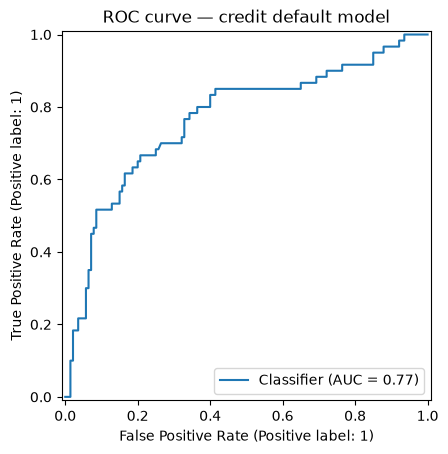

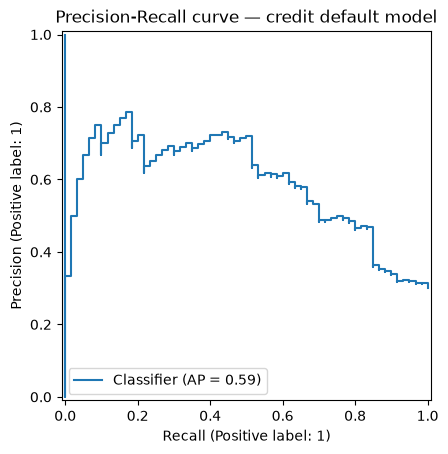

In [40]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["good (0)", "bad (1)"]))
test_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {test_auc:.3f}\n")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC curve — credit default model")
plt.savefig(f"{FIG_DIR}/roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall curve — credit default model")
plt.savefig(f"{FIG_DIR}/pr_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## Cost-based decision threshold

At the default 0.5 the model catches less than half the defaulters (recall(bad) ≈ 0.48): too permissive for a lender. So I do not decide at 0.5. In credit a false negative (lending to a defaulter → lost capital) costs far more than a false positive (rejecting a good client → lost margin), so I pick the threshold that minimizes expected cost under a 5:1 penalty.

Two things to be careful about. First, the threshold is chosen on out-of-fold predictions of the training set, never on the test set: tuning it on the test and then reporting test numbers at that same threshold would be optimistic. Second, the OOF cost curve is flat near its minimum, so the raw argmin is noise-driven; I keep the highest threshold whose cost stays within 10% of the minimum (a tolerance rule), which lands at 0.28.

Why 5:1 and tolerance 1.10. The sensitivity tables justify both: a 2:1 ratio catches too few defaulters (recall 0.52), a 10:1 is pathological (rejects ~70% of good clients); 5:1 is the sensible middle. The classification report at the operating threshold (0.28) is the one that matters in practice: recall(bad) rises to 0.67, not like the 0.5 report, which under-sells the model. Fig. 2c is the OOF cost curve (the red line is the tolerance-chosen 0.28, deliberately not the noisy raw minimum); Fig. 2d shows how the threshold moves with the cost ratio.

  threshold 0.50 -> recall(bad)=0.48  FN=31  FP=12  test_cost=167
  threshold 0.28 -> recall(bad)=0.67  FN=20  FP=35  test_cost=135
Cost-minimizing threshold (FN costs 5x FP): 0.28

              precision    recall  f1-score   support

    good (0)       0.84      0.75      0.79       140
     bad (1)       0.53      0.67      0.59        60

    accuracy                           0.72       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.72      0.73       200



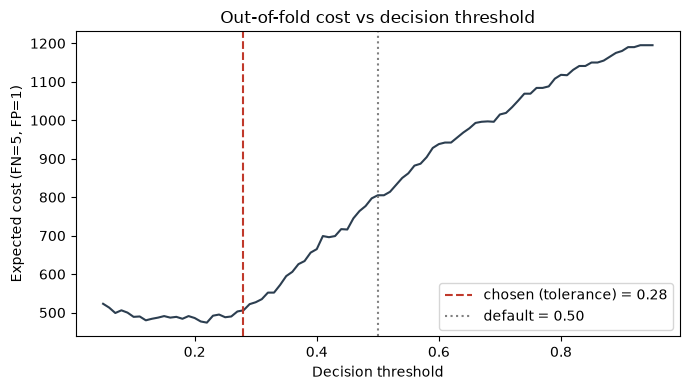

  FN:FP =  2:1 -> threshold 0.45  (test recall_bad=0.52, FP=17)
  FN:FP =  3:1 -> threshold 0.35  (test recall_bad=0.57, FP=21)
  FN:FP =  5:1 -> threshold 0.28  (test recall_bad=0.67, FP=35)
  FN:FP = 10:1 -> threshold 0.10  (test recall_bad=0.88, FP=100)
  tolerance 1.00 -> threshold 0.22
  tolerance 1.05 -> threshold 0.26
  tolerance 1.10 -> threshold 0.28
  tolerance 1.20 -> threshold 0.33



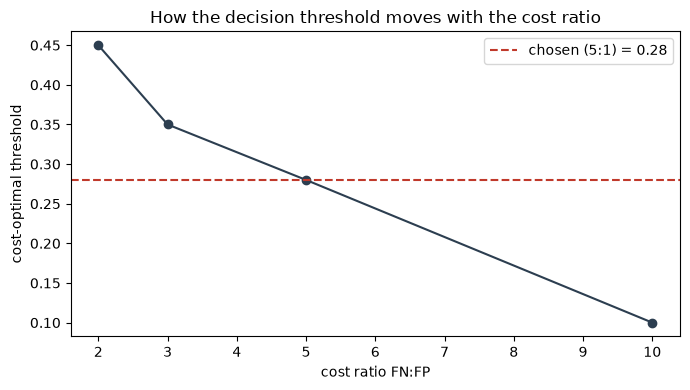

In [41]:
COST_FN, COST_FP = 5, 1
thresholds = np.linspace(0.05, 0.95, 91)

oof_proba = cross_val_predict(clone(model), X_train, y_train, cv=CV, method="predict_proba")[:, 1]
oof_costs = []
for t in thresholds:
    tn, fp, fn, tp = confusion_matrix(y_train, (oof_proba >= t).astype(int)).ravel()
    oof_costs.append(fn * COST_FN + fp * COST_FP)

COST_TOLERANCE = 1.10
min_cost = min(oof_costs)
eligible = [t for t, c in zip(thresholds, oof_costs) if c <= min_cost * COST_TOLERANCE]
best_t = float(max(eligible))

for t in [0.5, best_t]:
    tn, fp, fn, tp = confusion_matrix(y_test, (y_proba >= t).astype(int)).ravel()
    recall_bad = tp / (tp + fn)
    print(f"  threshold {t:.2f} -> recall(bad)={recall_bad:.2f}  "
          f"FN={fn}  FP={fp}  test_cost={fn*COST_FN+fp*COST_FP}")
print(f"Cost-minimizing threshold (FN costs {COST_FN}x FP): {best_t:.2f}\n")

print(classification_report(y_test, (y_proba >= best_t).astype(int),
                            target_names=["good (0)", "bad (1)"]))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, oof_costs, color="#2c3e50")
plt.axvline(best_t, color="#c0392b", linestyle="--", label=f"chosen (tolerance) = {best_t:.2f}")
plt.axvline(0.5, color="grey", linestyle=":", label="default = 0.50")
plt.xlabel("Decision threshold")
plt.ylabel(f"Expected cost (FN={COST_FN}, FP={COST_FP})")
plt.title("Out-of-fold cost vs decision threshold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/threshold_cost.png", dpi=120)
plt.show()

def optimal_threshold(cfn, cfp, tol):
    costs = [(lambda c: c[2] * cfn + c[1] * cfp)(
        confusion_matrix(y_train, (oof_proba >= t).astype(int)).ravel()) for t in thresholds]
    return max(t for t, c in zip(thresholds, costs) if c <= min(costs) * tol)

ratios, ratio_thr = [2, 3, 5, 10], []
for r in ratios:
    t = optimal_threshold(r, 1, COST_TOLERANCE)
    tn, fp, fn, tp = confusion_matrix(y_test, (y_proba >= t).astype(int)).ravel()
    ratio_thr.append(t)
    print(f"  FN:FP = {r:2d}:1 -> threshold {t:.2f}  (test recall_bad={tp/(tp+fn):.2f}, FP={fp})")

for tol in [1.00, 1.05, 1.10, 1.20]:
    print(f"  tolerance {tol:.2f} -> threshold {optimal_threshold(COST_FN, COST_FP, tol):.2f}")
print()

plt.figure(figsize=(7, 4))
plt.plot(ratios, ratio_thr, marker="o", color="#2c3e50")
plt.axhline(best_t, color="#c0392b", linestyle="--",
            label=f"chosen ({COST_FN}:{COST_FP}) = {best_t:.2f}")
plt.xlabel("cost ratio FN:FP")
plt.ylabel("cost-optimal threshold")
plt.title("How the decision threshold moves with the cost ratio")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/threshold_sensitivity.png", dpi=120)
plt.show()

## Explainability: SHAP

The core of the project: not what the model predicts but why. I use two independent methods, SHAP (game-theoretic, exact for trees) and LIME (local linear surrogate), so that agreement between them increases trust.

Global. The beeswarm and the per-dummy bar (Fig. 3a/3b) show every encoded feature. One thing must be mentioned: "no checking account" pushes risk down. That is a documented German-Credit quirk (clients with no checking record repay better here), not a bug.

Grouped importance (Fig. 3c). One-hot splits a variable across several dummies, so the per-dummy bar understates categoricals. SHAP is additive, so the honest per-variable importance is mean|sum of the dummy contributions per client|: I sum the dummies within each client first, then take the mean abs. Summing each dummy's mean|shap| instead would overstate categoricals vs the single-column continuous features, since the dummies' signs cannot cancel. Grouped this way, `Checking_account` clearly dominate as the known German-Credit pattern shows.

Dependence (Fig. 3d). A dependence plot is pointless on a binary feature (just two stripes), so I pick the strongest continuous feature, `amount_per_month`. Its relation is inverse (low installment → higher risk): a low monthly installment usually means a long-duration loan, the riskier profile, so it acts partly as a proxy for `Duration`.

Local (Fig. 3e). The waterfall explains the single riskiest applicant (the GDPR-style "why was this client flagged"). Sanity check: the waterfall `f(x)` is in log-odds; its sigmoid equals the predicted probability, and that probability matches LIME's below.

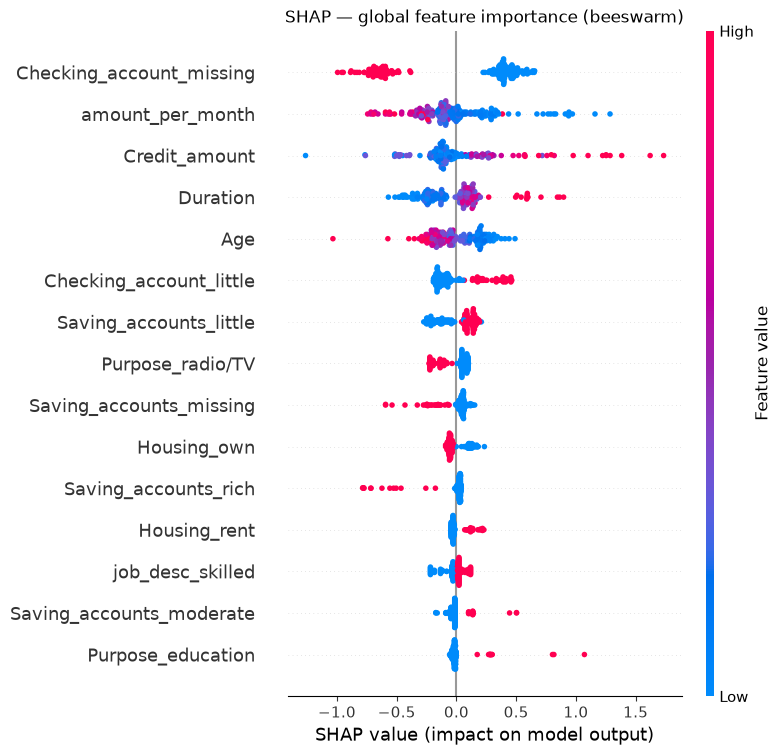

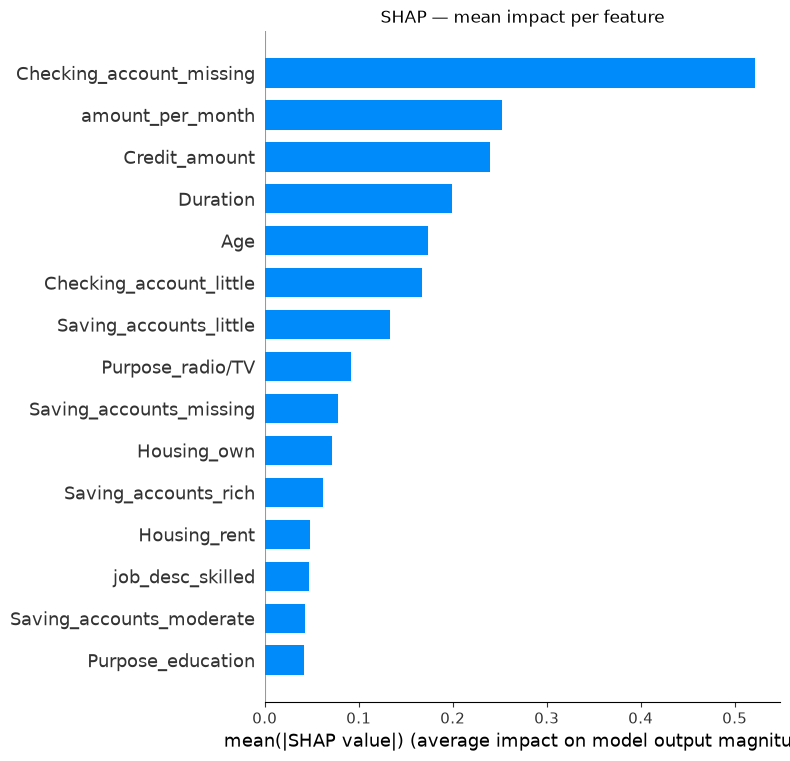

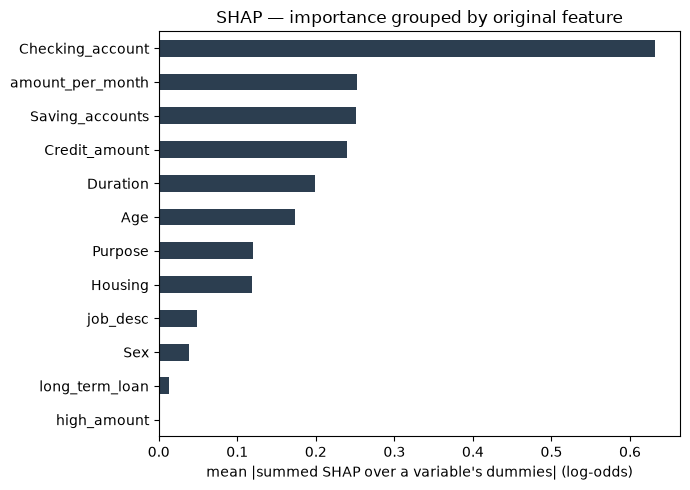

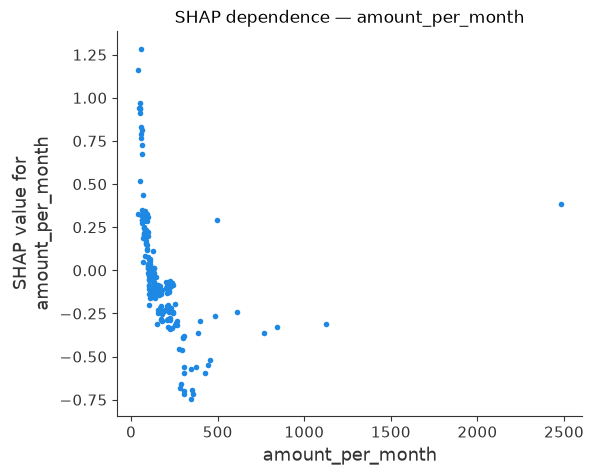

Explaining applicant #973 (test position 196):  predicted default risk: 0.88


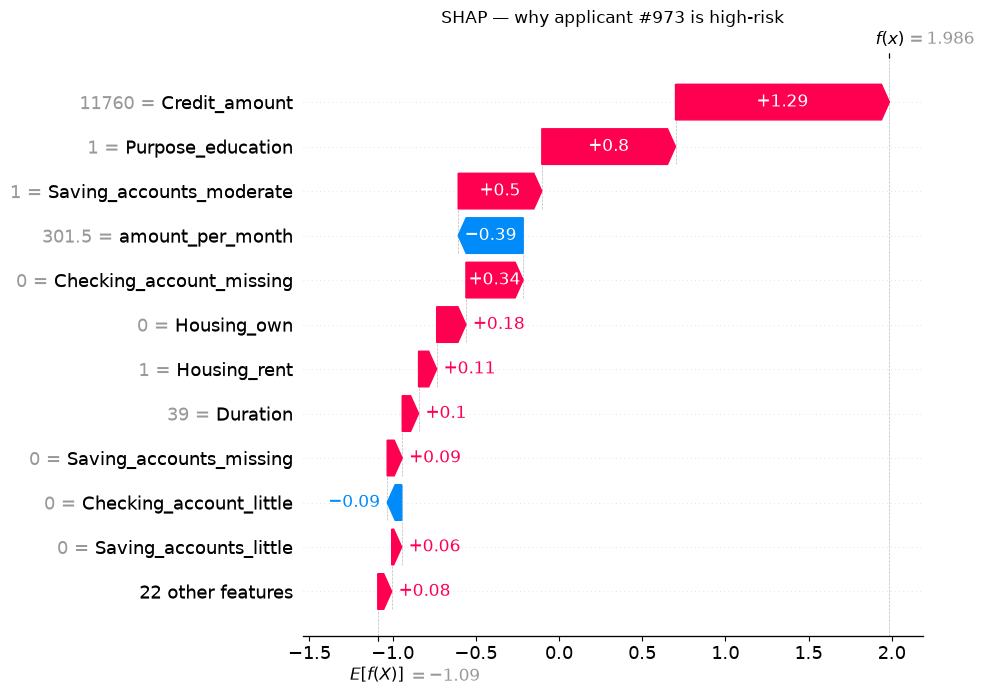

In [42]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X_test)   # note: values are in log-odds (margin) space
mean_abs_shap = pd.Series(np.abs(explanation.values).mean(axis=0), index=X_test.columns)

shap.summary_plot(explanation.values, X_test, show=False, max_display=15)
plt.title("SHAP — global feature importance (beeswarm)")
plt.savefig(f"{FIG_DIR}/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

shap.summary_plot(explanation.values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — mean impact per feature")
plt.savefig(f"{FIG_DIR}/shap_bar.png", dpi=120, bbox_inches="tight")
plt.show()

def base_feature(col):
    for c in categorical_cols:
        if col.startswith(c + "_"):
            return c
    return col
shap_by_feature = (pd.DataFrame(explanation.values.T, index=X_test.columns)
                   .groupby(base_feature).sum())   # sum dummy contributions per client
grouped_shap = shap_by_feature.abs().mean(axis=1).sort_values(ascending=False)
grouped_shap.head(12).iloc[::-1].plot(kind="barh", color="#2c3e50", figsize=(7, 5))
plt.xlabel("mean |summed SHAP over a variable's dummies| (log-odds)")
plt.title("SHAP — importance grouped by original feature")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_grouped.png", dpi=120, bbox_inches="tight")
plt.show()

continuous = [c for c in X_test.columns if X_test[c].nunique() > 2]
dep_feature = mean_abs_shap[continuous].idxmax()
shap.dependence_plot(dep_feature, explanation.values, X_test,
                     show=False, interaction_index=None)
plt.title(f"SHAP dependence — {dep_feature}")
plt.savefig(f"{FIG_DIR}/shap_dependence.png", dpi=120, bbox_inches="tight")
plt.show()

idx = int(y_proba.argmax())
applicant_id = int(X_test.index[idx])
print(f"Explaining applicant #{applicant_id} (test position {idx}): "
      f" predicted default risk: {y_proba[idx]:.2f}")
shap.plots.waterfall(explanation[idx], max_display=12, show=False)
plt.title(f"SHAP — why applicant #{applicant_id} is high-risk")
plt.savefig(f"{FIG_DIR}/shap_waterfall.png", dpi=120, bbox_inches="tight")
plt.show()

## Explainability: LIME

LIME explains the same applicant with a different technique. The catch: SHAP values here are in log-odds while LIME is in probability, so they are not comparable in magnitude. I therefore compare only what is scale-free: the sign of each contribution (direction) and the rank of the magnitudes (Spearman). The result is clean: sign agreement 9/10 and rank correlation ≈ 0.55, so the two methods agree on direction, less on the exact ranking (the one disagreement is on a near-zero feature).

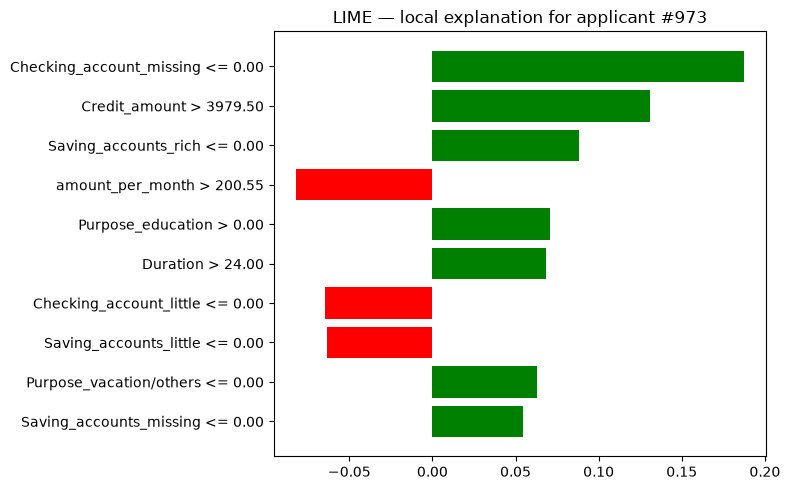

SHAP vs LIME on applicant #973: sign agreement 9/10, rank corr 0.55


In [43]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=["good", "bad"],
    mode="classification",
    random_state=RANDOM_STATE)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.values[idx],
    predict_fn=model.predict_proba,
    num_features=10)

lime_exp.save_to_file(f"{FIG_DIR}/lime_explanation.html")
fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.title(f"LIME — local explanation for applicant #{applicant_id}")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/lime_explanation.png", dpi=120)
plt.show()

lime_weights = {X_train.columns[i]: w for i, w in lime_exp.as_map()[1]}
shap_inst = pd.Series(explanation.values[idx], index=X_test.columns)
sign_agree = int(sum(np.sign(shap_inst[f]) == np.sign(w) for f, w in lime_weights.items()))
rank_corr = spearmanr([abs(shap_inst[f]) for f in lime_weights],
                      [abs(w) for w in lime_weights.values()]).correlation
print(f"SHAP vs LIME on applicant #{applicant_id}: "
      f"sign agreement {sign_agree}/{len(lime_weights)}, rank corr {rank_corr:.2f}")

## Fairness audit

`Sex` and `Age` are protected attributes. No single statute bans a column outright, but using them in credit decisions raises discrimination risk under German anti-discrimination law (AGG) and the EU Gender Directive 2004/113, so best practice excludes them. I keep `Sex` in the model only to audit how much it weighs: the XAI tools makes that measurable instead of a guess. Fairness is not one number, so I look at it from four angles:

- base rate: the groups genuinely differ (women default more, 35% vs 28%), so "fair" is not obvious;
- demographic parity (Disparate Impact, the 80% rule): fails at 0.79;
- equal opportunity: among clients with the same true outcome, good women are falsely rejected far more (35.7% vs 20.4%), which is the concrete harm;
- SHAP reliance: `Sex` is only ~2% of the grouped impact (rank #10 of 13).

Mitigation experiment. I then retrain without the protected attributes and re-audit. The interesting bit: `Sex` has a tiny SHAP share yet removing it still moves the DI (0.79 → 0.95), so the model was using it mainly through interactions, not as a standalone effect. Here unawareness happens to improve every axis, but the sample is small (only 64 women in test), so these rates are noisy and the DI comparison is partly threshold-driven.

  ACTUAL default rate (female ): 35.2%
  ACTUAL default rate (male   ): 27.7%
  approval rate (female ): 53.12%
  approval rate (male   ): 66.91%
  Disparate Impact ratio: 0.79 (FAIL the 80% rule)
  false-rejection rate among GOOD clients (female ): 35.71%
  false-rejection rate among GOOD clients (male   ): 20.41%
  Equal-opportunity gap (false-rejection of good clients): 0.15
  Sex grouped mean|SHAP| share: 1.9% of total impact (Sex ranks #10 of 13 original features)
  test-set group sizes: {'male': 136, 'female': 64}
  scenario                      DI   EO-gap  test-AUC
  with Sex+Age (baseline)     0.79     0.15     0.766
  without Sex                 0.85     0.13     0.768
  without Sex+Age             0.95     0.05     0.771


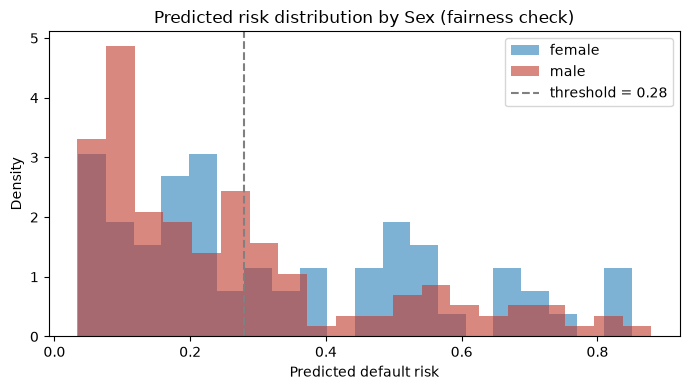

In [44]:
sex_cols = [c for c in X_test.columns if c.startswith("Sex_")]
decisions = pd.DataFrame({
    "Sex": sex_test.values,
    "approved": (y_proba < best_t).astype(int),
    "y_true": y_test.values,
}, index=sex_test.index)

base_rate = df.groupby("Sex")["default_flag"].mean()
for sex, r in base_rate.items():
    print(f"  ACTUAL default rate ({sex:7s}): {r:.1%}")

approval_by_sex = decisions.groupby("Sex")["approved"].mean()
di_ratio = approval_by_sex.min() / approval_by_sex.max()
for sex, rate in approval_by_sex.items():
    print(f"  approval rate ({sex:7s}): {rate:.2%}")
print(f"  Disparate Impact ratio: {di_ratio:.2f} "
      f"({'PASS' if di_ratio >= 0.8 else 'FAIL'} the 80% rule)")

good = decisions[decisions["y_true"] == 0]
false_reject = (1 - good.groupby("Sex")["approved"].mean())  # rejected good clients
eo_gap = float(false_reject.max() - false_reject.min())
for sex, r in false_reject.items():
    print(f"  false-rejection rate among GOOD clients ({sex:7s}): {r:.2%}")
print(f"  Equal-opportunity gap (false-rejection of good clients): {eo_gap:.2f}")

sex_shap = float(grouped_shap.get("Sex", 0.0))
sex_rank = int(grouped_shap.sort_values(ascending=False).index.get_indexer(["Sex"])[0]) + 1
print(f"  Sex grouped mean|SHAP| share: {sex_shap / grouped_shap.sum():.1%} of total "
      f"impact (Sex ranks #{sex_rank} of {len(grouped_shap)} original features)")

sex_counts = decisions["Sex"].value_counts().to_dict()
print(f"  test-set group sizes: {sex_counts}")

def evaluate_scenario(drop_cols):
    cols = [c for c in X_train.columns if c not in drop_cols]
    m = clone(model)
    m.fit(X_train[cols], y_train)
    oof = cross_val_predict(m, X_train[cols], y_train, cv=CV, method="predict_proba")[:, 1]
    costs = [confusion_matrix(y_train, (oof >= t).astype(int)).ravel() for t in thresholds]
    costs = [fn * COST_FN + fp * COST_FP for (tn, fp, fn, tp) in costs]
    thr = max(t for t, c in zip(thresholds, costs) if c <= min(costs) * COST_TOLERANCE)
    proba = m.predict_proba(X_test[cols])[:, 1]
    appr = pd.Series((proba < thr).astype(int), index=X_test.index)
    rate = appr.groupby(sex_test).mean()
    di = rate.min() / rate.max()
    g = (y_test.values == 0)
    fr = (1 - appr[g].groupby(sex_test[g]).mean())
    return {"di": float(di), "eo_gap": float(fr.max() - fr.min()),
            "auc": roc_auc_score(y_test, proba)}

age_cols = [c for c in X_train.columns if c == "Age"]
scenarios = {
    "with Sex+Age (baseline)": {"di": float(di_ratio), "eo_gap": eo_gap, "auc": test_auc},
    "without Sex":             evaluate_scenario(sex_cols),
    "without Sex+Age":         evaluate_scenario(sex_cols + age_cols),}

print(f"  {'scenario':26s} {'DI':>5s}  {'EO-gap':>7s}  {'test-AUC':>8s}")
for name, m in scenarios.items():
    print(f"  {name:26s} {m['di']:5.2f}  {m['eo_gap']:7.2f}  {m['auc']:8.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
for sex, color in zip(sorted(decisions["Sex"].unique()), ["#2980b9", "#c0392b"]):
    mask = decisions["Sex"].values == sex
    ax.hist(y_proba[mask], bins=20, alpha=0.6, color=color, label=sex, density=True)
ax.axvline(best_t, color="grey", linestyle="--", label=f"threshold = {best_t:.2f}")
ax.set_xlabel("Predicted default risk")
ax.set_ylabel("Density")
ax.set_title("Predicted risk distribution by Sex (fairness check)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fairness_risk_by_sex.png", dpi=120)
plt.show()

## Save artifacts

I persist the fitted model, the exact column layout (so a consumer can reproduce the encoding for a new applicant), a `feature_config.json` with the only train-fitted constant that feeds the engineered features (the train 75th percentile of `Credit_amount` behind the `high_amount` flag) plus the operating threshold, and a `metrics.json` summary that includes the fairness numbers. The demo app reads these to rebuild a new applicant's feature vector exactly as in training.

In [ ]:
joblib.dump(model, "credit_model.pkl")
joblib.dump(list(X_train.columns), "model_columns.pkl")

feature_config = {
    "credit_amount_q75": round(float(X_train_raw["Credit_amount"].quantile(0.75)), 1),
    "operating_threshold": round(best_t, 2),
    "duration_long_term_months": 24,
    "missing_account_token": "missing",
    "job_desc_map": {"0": "unskilled_non_resident", "1": "unskilled_resident",
                     "2": "skilled", "3": "highly_skilled"},
}
with open("feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

metrics = {
    "cv_roc_auc": {k: round(v[0], 3) for k, v in cv_results.items()},
    "best_params": grid.best_params_,
    "test_roc_auc": round(test_auc, 3),
    "optimal_threshold": round(best_t, 2),
    "riskiest_applicant_id": applicant_id,
    "riskiest_applicant_risk": round(float(y_proba[idx]), 2),
    "fairness": {
        "base_default_rate_by_sex": {k: round(float(v), 3) for k, v in base_rate.items()},
        "approval_rate_by_sex": {k: round(float(v), 3) for k, v in approval_by_sex.items()},
        "disparate_impact_ratio": round(float(di_ratio), 2),
        "equal_opportunity_gap": round(eo_gap, 2),
        "sex_shap_share": round(sex_shap / float(grouped_shap.sum()), 3),
        "mitigation": {name: {"di": round(m["di"], 2), "eo_gap": round(m["eo_gap"], 2),
                              "auc": round(float(m["auc"]), 3)}
                       for name, m in scenarios.items()}}}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

## Additional information

The deeper caveats, kept apart from the main flow.

Small test sample. The split leaves 200 test rows, ~60 of them women, so the fairness rates and the mitigation DI are low-power and should be read as indicative; a proper version would add a bootstrap confidence interval on the Disparate Impact.

In-fold leakage (acknowledged, not fixed). The train-fit feature (`high_amount`) is fit on the whole training set, so the CV folds in model selection share a sliver of information. The clean fix is to wrap the feature engineering in a scikit-learn Pipeline recomputed per fold; the effect is negligible and does not touch the reported test metric (the test set is fully held out), so I left it explicit for clarity.

Fairness impossibility (theory). Because the groups have different real default rates, you cannot make both the approval rates equal (demographic parity) and the error rates equal (equal opportunity) at once: enforcing one unbalances the other, and which to prioritise is a policy choice. This is a theoretical limit; this run does not show the trade-off (unawareness improved every axis) only because the test set is small and noisy.

Cost ratio is a business assumption, the 5:1 FN:FP penalty is not learned from data. A defaulter loses capital (thousands), a rejected good client loses interest margin (hundreds), so a few-times penalty is realistic; a deeper version would scale the cost by the loan amount.

Dead features kept on purpose. `high_amount`, `thin_file` and `long_term_loan` contribute ~0 in the grouped SHAP and could be pruned. I keep them as readable business flags: useful information to collect even if this model does not lean on them. Of the SQL-engineered features, `amount_per_month` and `job_desc` are the ones that actually carry weight.